In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.fft
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from gnlse import plot_intensity

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
data1 = np.load('./total_fields_3.npy')
data2 = np.load('./total_fields_4.npy')
total_data = np.concatenate([data1, data2], axis=0)
print(total_data.shape)
print(total_data.dtype)

(32, 21, 64, 64, 2048)
complex64


In [5]:
core_radius = 16.0e-6 / 2
Lx, Ly = 4 * core_radius, 4 * core_radius
Nx, Ny = 64, 64
extent = [-Lx/2, Lx/2, -Ly/2, Ly/2]

In [6]:
test_fields_input = total_data[-1][0]
test_fields_output = total_data[-1][-1]

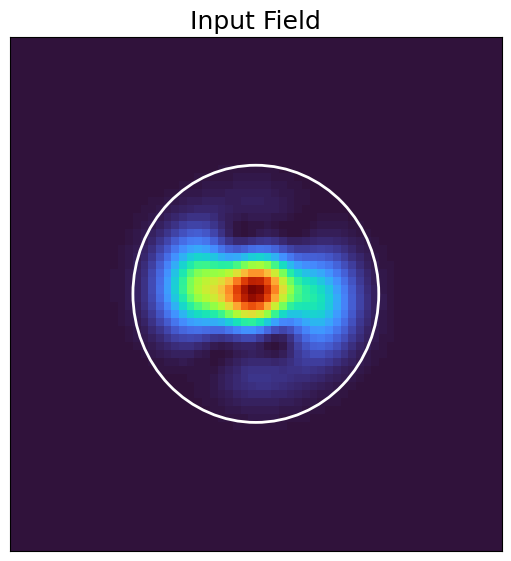

In [7]:
plot_intensity(test_fields_input, radius=core_radius, extent=extent, title='Input Field')

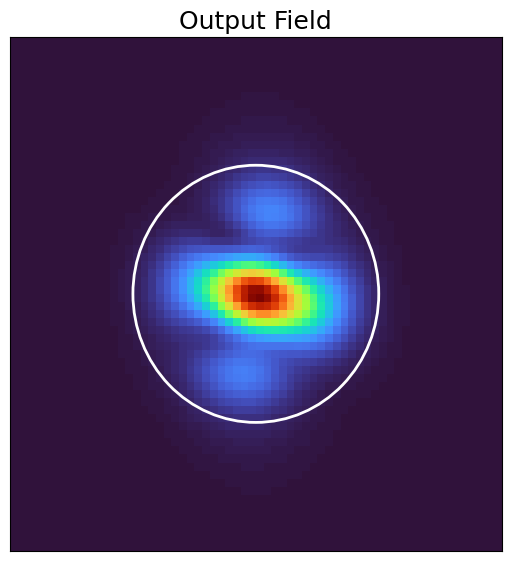

In [8]:
plot_intensity(test_fields_output, radius=core_radius, extent=extent, title='Output Field')

In [9]:
class SpectralConv3d(nn.Module):
    def __init__(self, in_channels, out_channels, modes, bias=True):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        # modes = (modes_x, modes_y, modes_t)
        self.modes_x, self.modes_y, self.modes_t = modes
        scale = 1 / (in_channels * out_channels)
        self.weight = nn.Parameter(scale * torch.randn(in_channels, out_channels,
                                                       self.modes_x, self.modes_y, self.modes_t, dtype=torch.cfloat))
        self.bias = nn.Parameter(torch.zeros(out_channels)) if bias else None

    def compl_mul3d(self, input, weights):
        # input: (B, in_c, kx, ky, kt)
        # weights: (in_c, out_c, kx, ky, kt)
        return torch.einsum("bixyz,ioxyz->boxyz", input, weights)

    def forward(self, x):
        B, C, X, Y, T = x.shape
        x = torch.fft.fftn(x, dim=(-3, -2, -1))  # 3D FFT over (x, y, t)
        out = torch.zeros(B, self.out_channels, X, Y, T, dtype=torch.cfloat, device=x.device)

        # Only keep low-frequency modes
        out[:, :, :self.modes_x, :self.modes_y, :self.modes_t] = \
            self.compl_mul3d(x[:, :, :self.modes_x, :self.modes_y, :self.modes_t],
                             self.weight)

        # iFFT back to real space
        out = torch.fft.ifftn(out, dim=(-3, -2, -1))
        if self.bias is not None:
            out = out + self.bias.view(1, -1, 1, 1, 1)
        return out.real  # real tensor for next layers (split real/imag separately later if needed)


# ========================
# 3D FNO Block
# ========================
class FNO3DBlock(nn.Module):
    def __init__(self, in_channels, out_channels, modes=(12, 12, 12), width=64):
        super().__init__()
        self.spectral_conv = SpectralConv3d(in_channels, out_channels, modes)
        self.pointwise_conv = nn.Conv3d(in_channels, out_channels, 1)
        self.activation = nn.GELU()

    def forward(self, x):
        out = self.spectral_conv(x) + self.pointwise_conv(x)
        return x + self.activation(out)
        # return self.activation(out)

# ========================
# 3D FNO Model
# ========================
class FNO3D(nn.Module):
    def __init__(self, in_channels=2, out_channels=2, width=32, n_layers=4,
                 modes=(12, 12, 12)):
        super().__init__()
        self.input_proj = nn.Conv3d(in_channels, width, 1)
        self.fno_layers = nn.ModuleList([
            FNO3DBlock(width, width, modes, width) for _ in range(n_layers)
        ])
        self.output_proj = nn.Sequential(
            nn.Conv3d(width, width // 2, 1),
            nn.GELU(),
            nn.Conv3d(width // 2, out_channels, 1)
        )

    def forward(self, x):
        # x: (B, 2, X, Y, T)
        x = self.input_proj(x)
        for layer in self.fno_layers:
            x = layer(x)
        return self.output_proj(x)

In [14]:
input_data = total_data[:, :1, :, :, :]
output_data = total_data[:, -1:, :, :, :]

In [15]:
num_data = total_data.shape[0]
n_train = int(num_data*0.8)
n_test = num_data - n_train
print(f'train : {n_train}, test : {n_test}')

train : 25, test : 7


In [16]:
train_input_data = input_data[0:n_train]
train_output_data = output_data[0:n_train]
test_input_data = input_data[n_train:]
test_output_data = output_data[n_train:]

In [17]:
#complex dtype to real dtype with split real and imag, [M, 1, X, Y, T] -> [M, 2, X, Y, T]
train_input_data = np.concatenate([train_input_data.real, train_input_data.imag], axis=1)
train_output_data = np.concatenate([train_output_data.real, train_output_data.imag], axis=1)
test_input_data = np.concatenate([test_input_data.real, test_input_data.imag], axis=1)
test_output_data = np.concatenate([test_output_data.real, test_output_data.imag], axis=1)
print(train_input_data.shape, train_output_data.shape, flush=True)
print(test_input_data.shape, test_output_data.shape, flush=True)

(25, 2, 64, 64, 2048) (25, 2, 64, 64, 2048)
(7, 2, 64, 64, 2048) (7, 2, 64, 64, 2048)


In [21]:
# Hyperparameters
lr = 0.01
batch_size = 4
epochs = 100
width = 16
num_layers = 4
mode_x, mode_y, mode_t = 16, 16, 16

In [19]:
# Define a model
model = FNO3D(
        in_channels=2,
        out_channels=2,
        width=width,
        n_layers=num_layers,
        modes=(mode_x, mode_y, mode_t),
        ).to(device)

optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
loss_fn = nn.MSELoss()


In [20]:
# Print the number of tunable parameters
print('Number of parameters : ',flush=True)
print(sum(p.numel() for p in model.parameters() if p.requires_grad))

Number of parameters : 
4195658


In [22]:
total_loss = 0
total_test_loss = 0
eps = 1e-8
total_loss_list = []
total_test_loss_list = []

# scaler = torch.cuda.amp.GradScaler()    

for epoch in range(epochs):
    model.train()
    for i in range(0, train_input_data.shape[0], batch_size):
        optimizer.zero_grad()
        inp = torch.tensor(train_input_data[i:i+batch_size], device=device)
        target = torch.tensor(train_output_data[i:i+batch_size], device=device)
        out = model(inp)
        loss = loss_fn(out, target) / (torch.mean(target**2) + eps)
        # with torch.cuda.amp.autocast():
        #     out = model(inp)        
        #     loss = loss_fn(out, target) / (torch.mean(target**2) + eps)
        total_loss = total_loss + loss.item()             
         
        # scaler.scale(loss).backward()
        # scaler.step(optimizer)
        # scaler.update()        
        loss.backward()
        optimizer.step()
        scheduler.step()
        # print(f"Epoch {epoch}, batch {i} training complete", flush=True)
    
    model.eval()
    with torch.no_grad():
        for i in range(0, test_input_data.shape[0], batch_size):
            test_input = torch.tensor(test_input_data[i:i+batch_size], device=device)
            test_target = torch.tensor(test_output_data[i:i+batch_size], device=device)
            test_out = model(test_input)
            test_loss = loss_fn(test_out, test_target) / (torch.mean(test_target**2) + eps)
            total_test_loss = total_test_loss + test_loss.item()
        
    print(f"Epoch {epoch}, Train Loss: {total_loss / n_train}, Test Loss: {total_test_loss / n_test}", flush=True)
    total_loss_list.append(total_loss / 900)
    total_test_loss_list.append(total_test_loss / 100)
    total_loss = 0
    total_test_loss = 0

Epoch 0, Train Loss: 0.27779431819915773, Test Loss: 0.2828105688095093
Epoch 1, Train Loss: 0.2666304874420166, Test Loss: 0.2829716546194894
Epoch 2, Train Loss: 0.2595474648475647, Test Loss: 0.2806263395718166
Epoch 3, Train Loss: 0.25438969373703, Test Loss: 0.281756443636758
Epoch 4, Train Loss: 0.2499962878227234, Test Loss: 0.28163195507866995
Epoch 5, Train Loss: 0.24734612226486205, Test Loss: 0.28228624377931866
Epoch 6, Train Loss: 0.24617125749588012, Test Loss: 0.28242110354559763
Epoch 7, Train Loss: 0.2459770369529724, Test Loss: 0.28241867678506033
Epoch 8, Train Loss: 0.24566819429397582, Test Loss: 0.28227845260075163
Epoch 9, Train Loss: 0.244078049659729, Test Loss: 0.2824789711407253
Epoch 10, Train Loss: 0.2401893711090088, Test Loss: 0.2837636045047215
Epoch 11, Train Loss: 0.23359304904937744, Test Loss: 0.2864184209278652
Epoch 12, Train Loss: 0.22495758771896363, Test Loss: 0.29070930821555
Epoch 13, Train Loss: 0.21317579746246337, Test Loss: 0.2943863698414

In [29]:
test = test_input_data[0]
test = np.reshape(test, (1, 2, 64, 64, 2048))
test = torch.tensor(test).to(device)
print(test.shape)

torch.Size([1, 2, 64, 64, 2048])


In [30]:
prediction = model(test)
print(prediction.shape)

torch.Size([1, 2, 64, 64, 2048])


In [32]:
test_field = prediction[0][0] + prediction[0][1]*1j
test_field = test_field.detach().cpu().numpy()

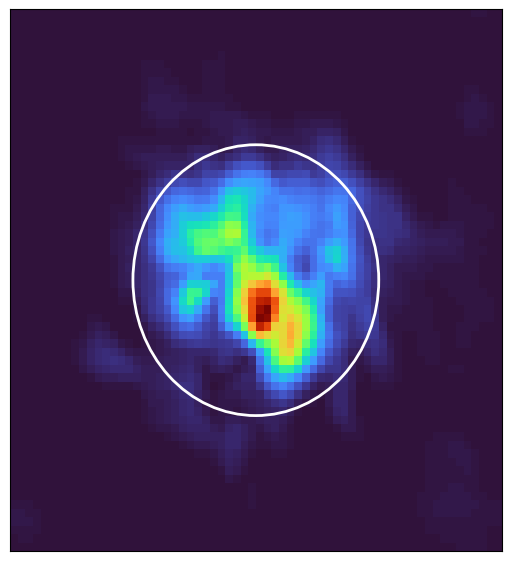

In [33]:
plot_intensity(test_field, radius=core_radius, extent=extent)

In [35]:
true_field = test_input_data[0][0] + test_input_data[0][1]*1j

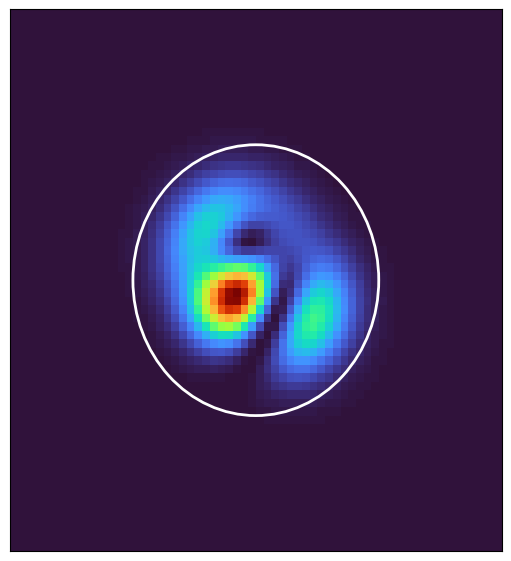

In [36]:
plot_intensity(true_field, radius=core_radius, extent=extent)